# Exploratory Data Analysis - Chicago Rideshare Demand

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

In [65]:
df = pd.read_parquet('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/data/processed/chirde.cleaned_data.parquet')
df.head()

,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_community_area,fare,tip,additional_charges,trip_total,shared_trip_authorized,shared_trip_match,trips_pooled,pickup_centroid_latitude,pickup_centroid_longitude
0,2024-12-31 23:45:00,2024-12-31 23:45:00,300.0,0.9,32,2.5,3.0,2.56,8.06,False,False,1,41.870605,-87.622169
1,2024-12-31 23:45:00,2025-01-01 00:00:00,860.0,4.6,6,15.0,0.0,4.50,19.50,False,False,1,41.949062,-87.661644
2,2024-12-31 23:45:00,2025-01-01 00:00:00,275.0,1.1,6,7.5,0.0,2.89,10.39,False,False,1,41.944225,-87.655998
3,2024-12-31 23:45:00,2024-12-31 23:45:00,588.0,0.6,8,5.0,0.0,2.63,7.63,False,False,1,41.890923,-87.618866
4,2024-12-31 23:45:00,2024-12-31 23:45:00,443.0,4.2,28,10.0,0.0,3.79,13.79,False,False,1,41.885281,-87.657234


In [66]:
df.shape

(4176957, 14)

In [67]:
df.describe()

,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_community_area,fare,tip,additional_charges,trip_total,trips_pooled,pickup_centroid_latitude,pickup_centroid_longitude
count,4176957,4176957,4.176957e+06,4.176957e+06,4.176957e+06,4.176957e+06,4.176957e+06,4.176957e+06,4.176957e+06,4.176957e+06,4.176957e+06,4.176957e+06
mean,2024-12-16 05:05:58.921625856,2024-12-16 05:15:39.595237888,5.798196e+02,2.564204e+00,2.505553e+01,1.015223e+01,7.641551e-01,3.279972e+00,1.419635e+01,1.057268e+00,4.188464e+01,-8.765841e+01
min,2024-12-01 00:00:00,2024-12-01 00:00:00,2.000000e+00,1.000000e-01,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,4.165022e+01,-8.791363e+01
25%,2024-12-08 01:00:00,2024-12-08 01:15:00,3.980000e+02,1.300000e+00,8.000000e+00,7.500000e+00,0.000000e+00,1.230000e+00,9.900000e+00,1.000000e+00,4.187061e+01,-8.767472e+01
50%,2024-12-15 12:15:00,2024-12-15 12:15:00,5.750000e+02,2.100000e+00,2.400000e+01,1.000000e+01,0.000000e+00,2.980000e+00,1.316000e+01,1.000000e+00,4.189207e+01,-8.764890e+01
75%,2024-12-23 00:15:00,2024-12-23 00:30:00,7.650000e+02,3.300000e+00,3.200000e+01,1.250000e+01,0.000000e+00,4.290000e+00,1.703000e+01,1.000000e+00,4.192276e+01,-8.762888e+01
max,2024-12-31 23:45:00,2025-01-01 00:15:00,9.990000e+02,2.000000e+01,7.700000e+01,2.000000e+02,8.300000e+01,3.037700e+02,3.262700e+02,3.900000e+01,4.202122e+01,-8.752995e+01
std,NaN,NaN,2.267370e+02,1.824993e+00,1.937711e+01,5.401021e+00,1.681140e+00,2.315335e+00,6.676846e+00,5.220341e-01,6.574957e-02,4.978310e-02


In [68]:
df.isnull().sum()

trip_start_timestamp         0
trip_end_timestamp           0
trip_seconds                 0
trip_miles                   0
pickup_community_area        0
fare                         0
tip                          0
additional_charges           0
trip_total                   0
shared_trip_authorized       0
shared_trip_match            0
trips_pooled                 0
pickup_centroid_latitude     0
pickup_centroid_longitude    0
dtype: int64

##### Extract Time Features

To understand how does demand change over time?

In [69]:
df['hour'] = df['trip_start_timestamp'].dt.hour
df['day_of_week'] = df['trip_start_timestamp'].dt.dayofweek
df['day_name'] = df['trip_start_timestamp'].dt.day_name()
df['date'] = df['trip_start_timestamp'].dt.date
df['week'] = df['trip_start_timestamp'].dt.isocalendar().week.astype(int)
df['is_weekend'] = df['day_of_week'].isin([5, 6])

print(df[['trip_start_timestamp', 'hour', 'day_of_week', 'day_name', 'date', 'week', 'is_weekend']].head(10))

  trip_start_timestamp  hour  day_of_week day_name        date  week  \
0  2024-12-31 23:45:00    23            1  Tuesday  2024-12-31     1   
1  2024-12-31 23:45:00    23            1  Tuesday  2024-12-31     1   
2  2024-12-31 23:45:00    23            1  Tuesday  2024-12-31     1   
3  2024-12-31 23:45:00    23            1  Tuesday  2024-12-31     1   
4  2024-12-31 23:45:00    23            1  Tuesday  2024-12-31     1   
5  2024-12-31 23:45:00    23            1  Tuesday  2024-12-31     1   
6  2024-12-31 23:45:00    23            1  Tuesday  2024-12-31     1   
7  2024-12-31 23:45:00    23            1  Tuesday  2024-12-31     1   
8  2024-12-31 23:45:00    23            1  Tuesday  2024-12-31     1   
9  2024-12-31 23:45:00    23            1  Tuesday  2024-12-31     1   

   is_weekend  
0       False  
1       False  
2       False  
3       False  
4       False  
5       False  
6       False  
7       False  
8       False  
9       False  


In [70]:
# Sample Data
SAMPLE_SIZE = 500_000
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42)

##### Daily Trip Volume

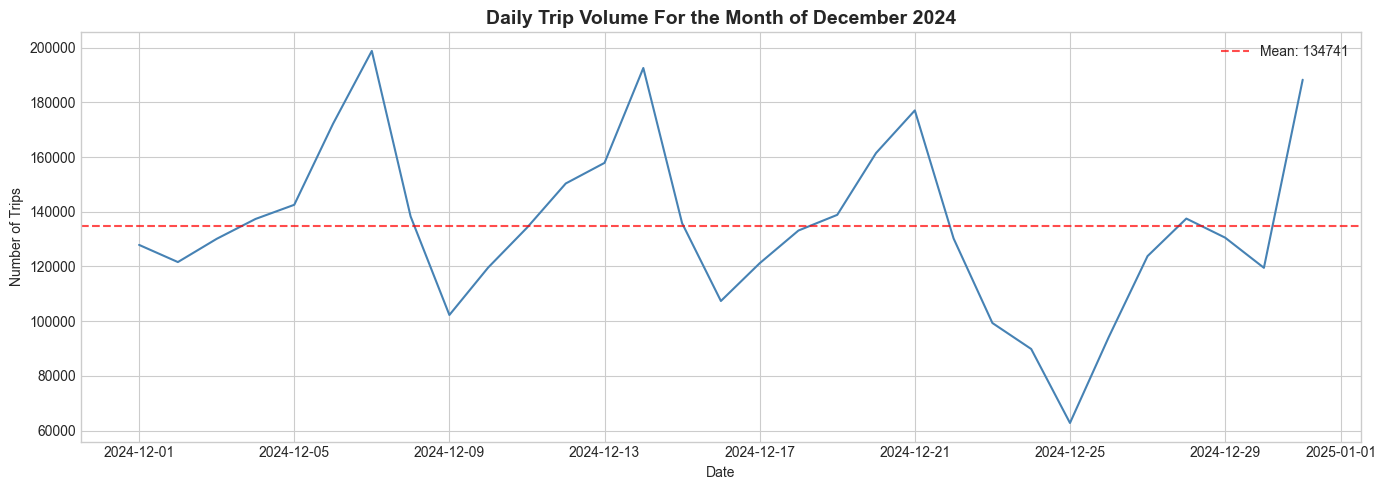

In [71]:
daily_trips = df.groupby('date').size()

fig, ax = plt.subplots(figsize = (14, 5))
daily_trips.plot(kind='line', ax=ax, linewidth=1.5, color='steelblue')
ax.set_title('Daily Trip Volume For the Month of December 2024', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Trips')
ax.axhline(daily_trips.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {daily_trips.mean():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

##### Day Of Week Pattern

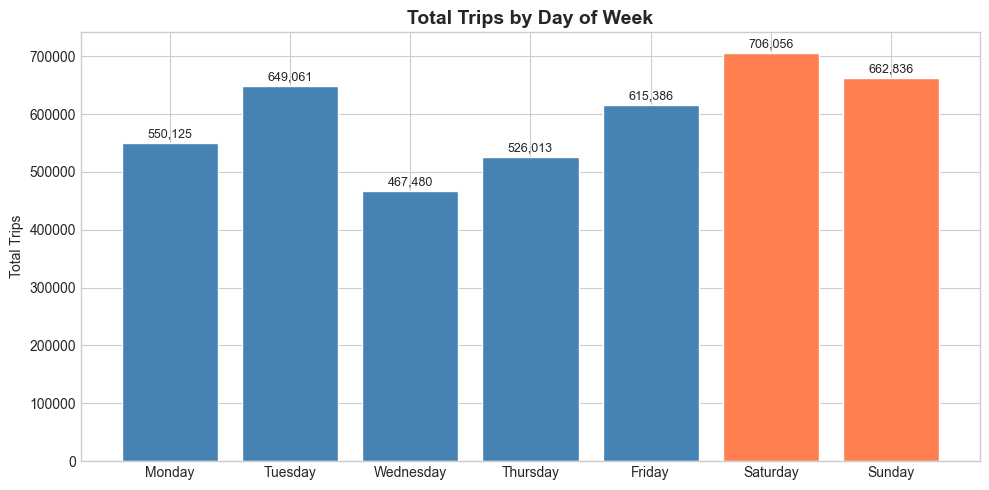

In [72]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_trips = df.groupby('day_name').size().reindex(dow_order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dow_order, dow_trips.values, color = ['steelblue']*5 + ['coral']*2, edgecolor='white')
ax.set_title('Total Trips by Day of Week', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Trips')

for bar, val in zip(bars, dow_trips.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5000, f'{val:,.0f}', ha='center', va='bottom', fontsize=9)


plt.tight_layout()
plt.show()

##### Hourly Pattern

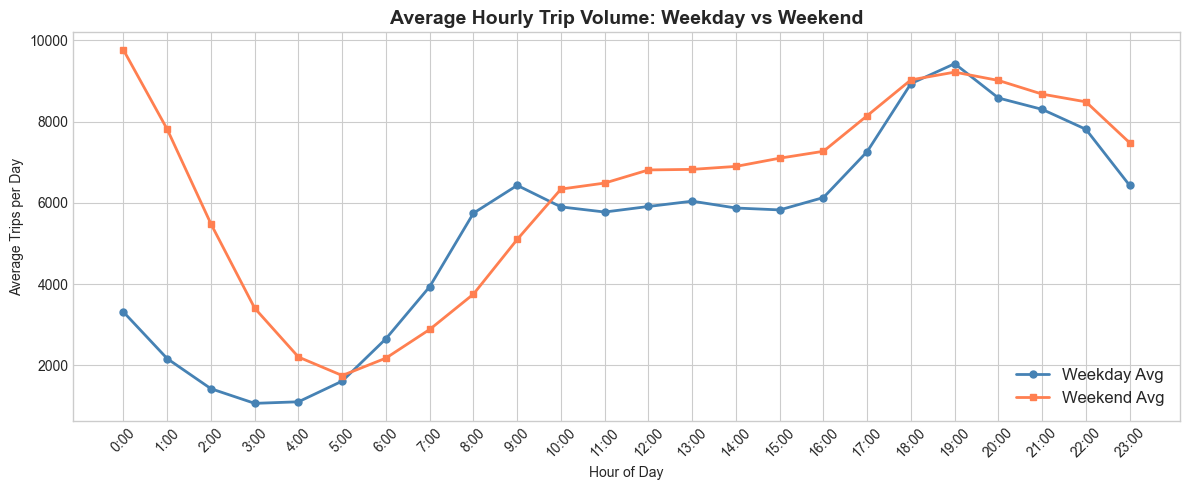

In [73]:
hourly_weekday = df[~df['is_weekend']].groupby('hour').size() / df[~df['is_weekend']]['date'].nunique()
hourly_weekend = df[df['is_weekend']].groupby('hour').size() / df[df['is_weekend']]['date'].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_weekday.index, hourly_weekday.values, 'o-', label='Weekday Avg', color='steelblue', linewidth=2, markersize=5)
ax.plot(hourly_weekend.index, hourly_weekend.values, 's-', label='Weekend Avg', color='coral', linewidth=2, markersize=5)
ax.set_title('Average Hourly Trip Volume: Weekday vs Weekend', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Trips per Day')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h}:00' for h in range(0, 24)], rotation=45)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

##### Hour x Day of Week

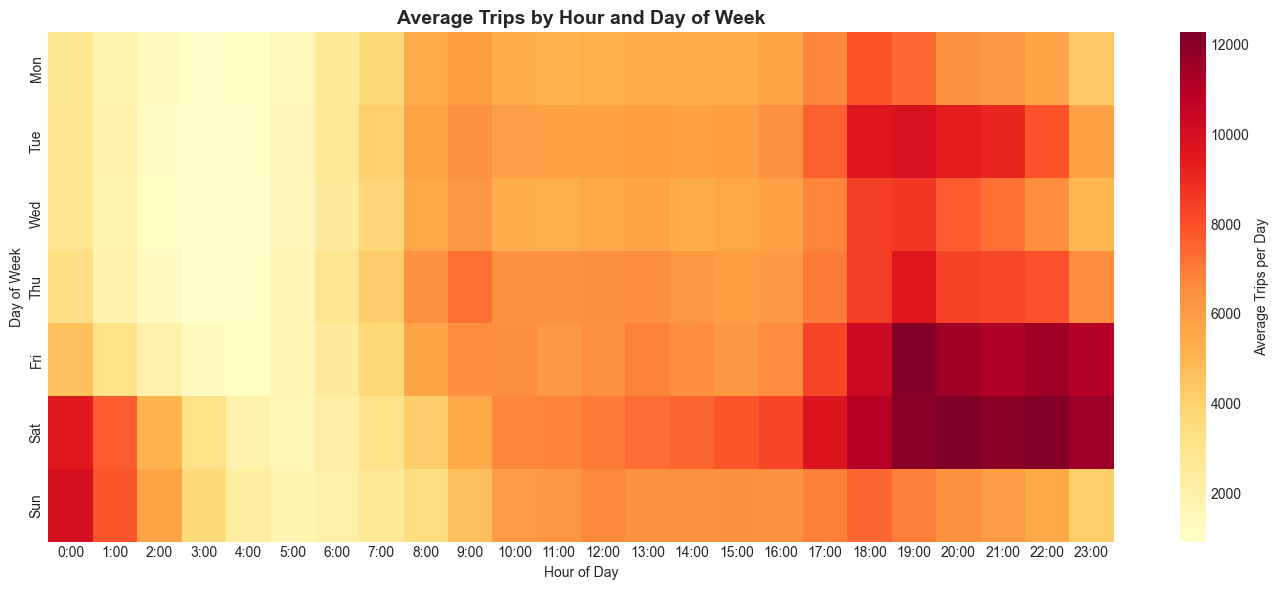

In [74]:
pivot  = df.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)

day_counts = df.groupby('day_of_week')['date'].nunique()
pivot_avg = pivot.div(day_counts, axis=0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_avg, cmap='YlOrRd', annot=False, fmt='.0f', xticklabels=[f'{h}:00' for h in range(24)], yticklabels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], ax=ax, cbar_kws={'label': 'Average Trips per Day'})
ax.set_title('Average Trips by Hour and Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.show()

##### Distribution of Trip Duration

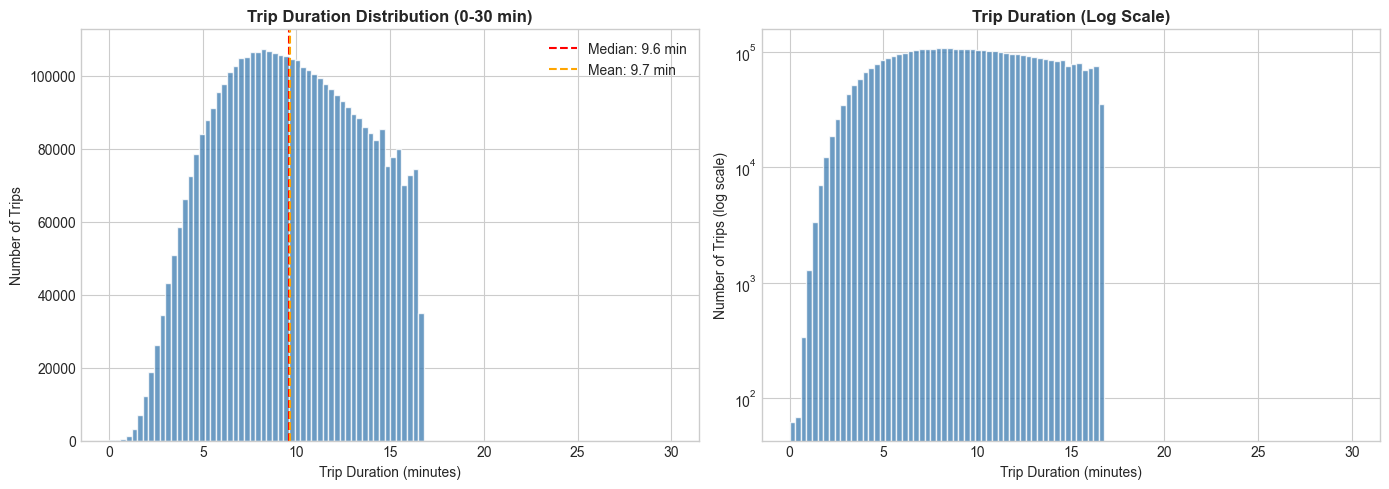

Trip duration percentiles (minutes):
25th percentile: 6.6 min
50th percentile: 9.6 min
75th percentile: 12.8 min
95th percentile: 15.8 min
99th percentile: 16.5 min


In [75]:
fig, ax = plt.subplots(1,2, figsize=(14, 5))

trip_minutes = df['trip_seconds'] / 60
ax[0].hist(trip_minutes, bins = 100, range=(0, 30), color='steelblue', edgecolor='white', alpha=0.8)
ax[0].set_title('Trip Duration Distribution (0-30 min)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Trip Duration (minutes)')
ax[0].set_ylabel('Number of Trips')
ax[0].axvline(trip_minutes.median(), color='red', linestyle='--', label=f'Median: {trip_minutes.median():.1f} min')
ax[0].axvline(trip_minutes.mean(), color='orange', linestyle='--', label=f'Mean: {trip_minutes.mean():.1f} min')
ax[0].legend()

ax[1].hist(trip_minutes, bins=100, range=(0, 30), color='steelblue', edgecolor='white', alpha=0.8)
ax[1].set_yscale('log')
ax[1].set_title('Trip Duration (Log Scale)', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Trip Duration (minutes)')
ax[1].set_ylabel('Number of Trips (log scale)')

plt.tight_layout()
plt.show()

print(f"Trip duration percentiles (minutes):")
for p in [25, 50, 75, 95, 99]:
    print(f"{p}th percentile: {np.percentile(trip_minutes, p):.1f} min")

##### Distribution of Trip Distance

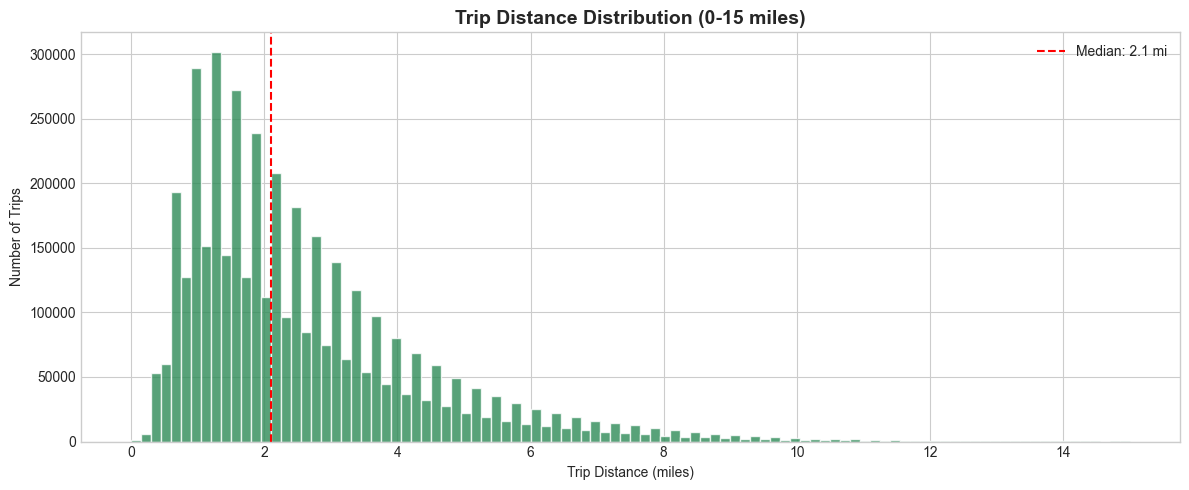


Trip distance percentiles (miles):
25th percentile: 1.3 mi
50th percentile: 2.1 mi
75th percentile: 3.3 mi
95th percentile: 6.3 mi
99th percentile: 8.9 mi


In [76]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['trip_miles'], bins=100, range=(0, 15), color='seagreen', edgecolor='white', alpha=0.8)
ax.set_title('Trip Distance Distribution (0-15 miles)', fontsize=14, fontweight='bold')
ax.set_xlabel('Trip Distance (miles)')
ax.set_ylabel('Number of Trips')
ax.axvline(df['trip_miles'].median(), color='red', linestyle='--', label=f'Median: {df["trip_miles"].median():.1f} mi')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nTrip distance percentiles (miles):")
for p in [25, 50, 75, 95, 99]:
    print(f"{p}th percentile: {np.percentile(df['trip_miles'], p):.1f} mi")

##### Fare Distribution

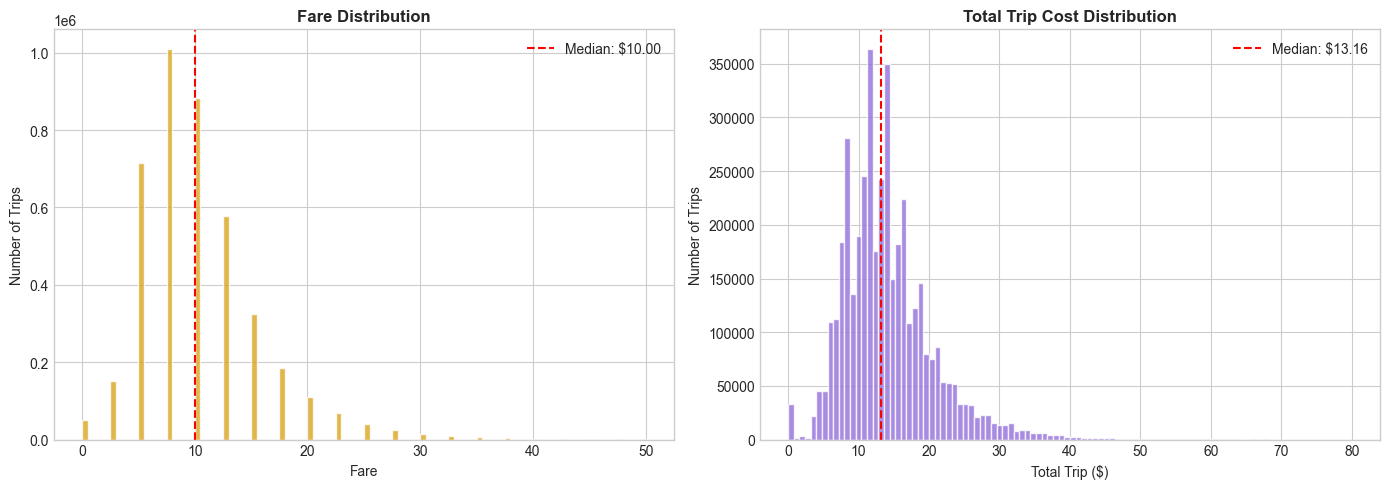

In [77]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(df['fare'], bins=100, range=(0, 50), color='goldenrod', edgecolor='white', alpha=0.8)
ax[0].set_title('Fare Distribution', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Fare')
ax[0].set_ylabel('Number of Trips')
ax[0].axvline(df['fare'].median(), color='red', linestyle='--', label=f'Median: ${df['fare'].median():.2f}')
ax[0].legend()

ax[1].hist(df['trip_total'], bins=100, range=(0, 80), color='mediumpurple', edgecolor='white', alpha=0.8)
ax[1].set_title('Total Trip Cost Distribution', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Total Trip ($)')
ax[1].set_ylabel('Number of Trips')
ax[1].axvline(df['trip_total'].median(), color='red', linestyle='--', label=f'Median: ${df['trip_total'].median():.2f}')
ax[1].legend()
plt.tight_layout()
plt.show()

##### Tipping Behavior

Trips with a tip: 23.7%
Average tip (when given): $3.22
Average tip (all trips): $0.76


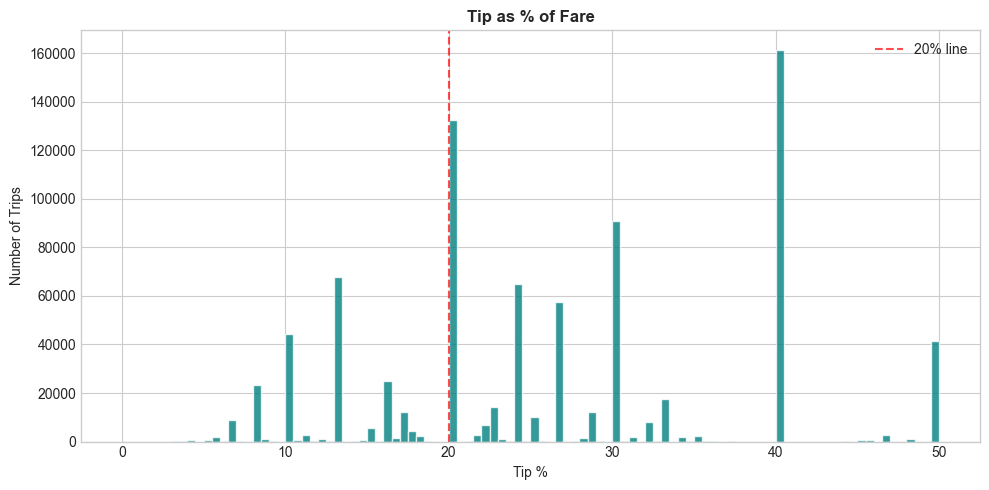

In [78]:
tip_rate = (df['tip'] > 0).mean() * 100
avg_tip = df.loc[df['tip'] > 0, 'tip'].mean()

print(f"Trips with a tip: {tip_rate:.1f}%")
print(f"Average tip (when given): ${avg_tip:.2f}")
print(f"Average tip (all trips): ${df['tip'].mean():.2f}")

tipped = df[df['tip'] > 0].copy()
tipped['tip_pct'] = (tipped['tip'] / tipped['fare']) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(tipped['tip_pct'], bins=100, range=(0, 50), color='teal', edgecolor='white', alpha=0.8)
ax.set_title('Tip as % of Fare', fontsize=12, fontweight='bold')
ax.set_xlabel('Tip %')
ax.set_ylabel('Number of Trips')
ax.axvline(20, color='red', linestyle='--', label='20% line', alpha=0.7)
ax.legend()
plt.tight_layout()
plt.show()

##### Top Pickup Areas

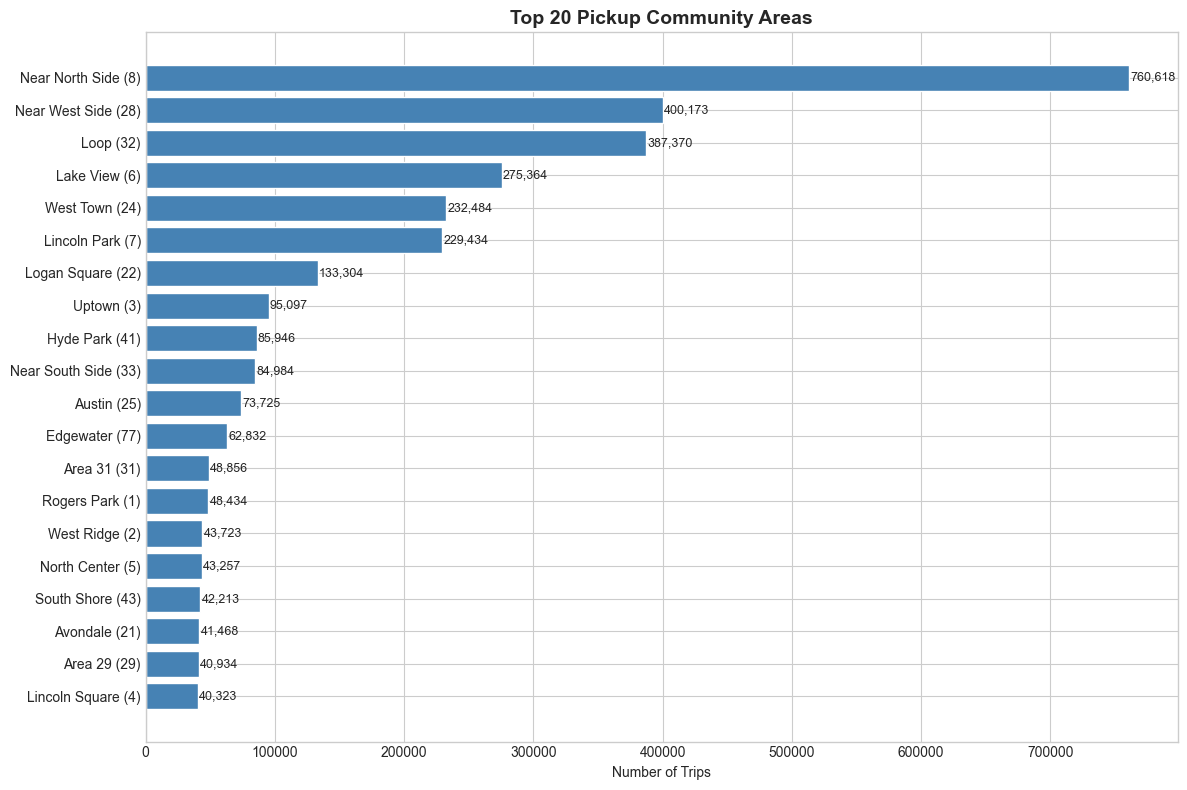

In [79]:
known = df[df['pickup_community_area'] != -1]
area_counts = known['pickup_community_area'].value_counts().head(20)

# Chicago community area codes
area_names = {
    8: 'Near North Side', 32: 'Loop', 28: 'Near West Side',
    76: 'O\'Hare', 6: 'Lake View', 24: 'West Town',
    33: 'Near South Side', 7: 'Lincoln Park', 22: 'Logan Square',
    56: 'Garfield Ridge', 3: 'Uptown', 77: 'Edgewater',
    1: 'Rogers Park', 2: 'West Ridge', 4: 'Lincoln Square',
    5: 'North Center', 14: 'Albany Park', 15: 'Portage Park',
    16: 'Irving Park', 17: 'Dunning', 21: 'Avondale',
    23: 'Humboldt Park', 25: 'Austin', 41: 'Hyde Park',
    43: 'South Shore', 64: 'Clearing', 35: 'Douglas'
}

fig, ax = plt.subplots(figsize=(12, 8))
labels = [f"{area_names.get(idx, f'Area {idx}')} ({idx})" for idx in area_counts.index]
bars = ax.barh(labels[::-1], area_counts.values[::-1], color='steelblue', edgecolor='white')
ax.set_title('Top 20 Pickup Community Areas', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Trips')

for bar, val in zip(bars, area_counts.values[::-1]):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height() / 2, f'{val:,}', ha='left', va='center', fontsize=9)


plt.tight_layout()
plt.show()

##### Pickup Location Map

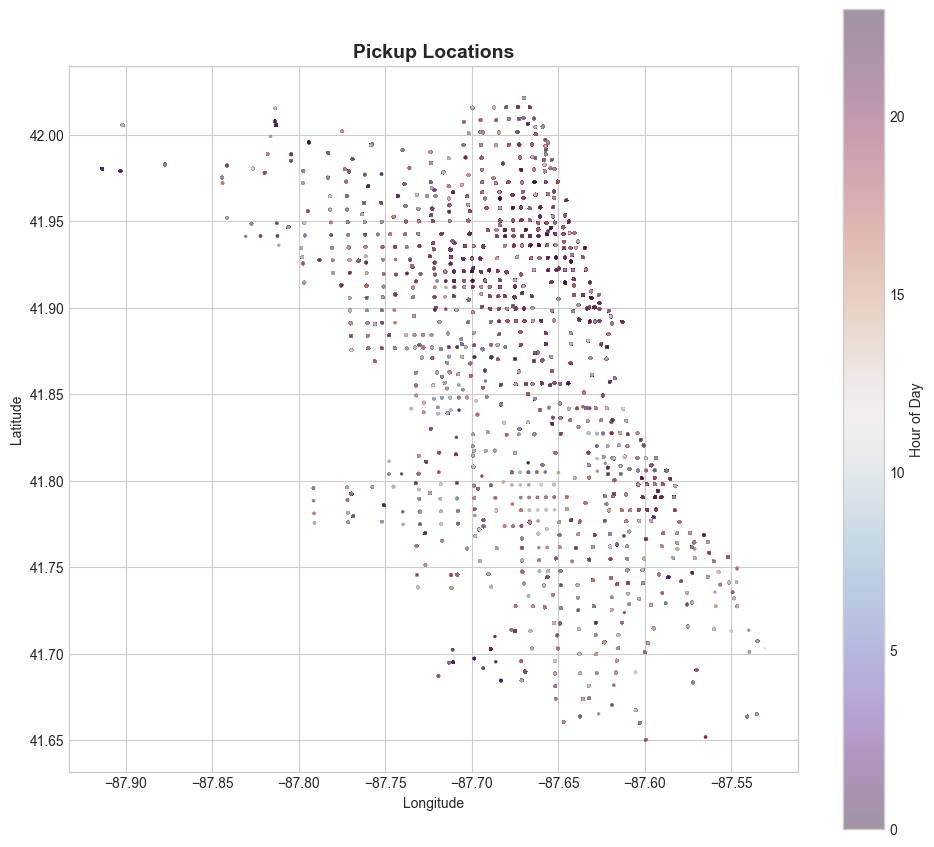

In [80]:
sample = df.dropna(subset = ['pickup_centroid_latitude', 'pickup_centroid_longitude']).sample(n = min(500000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 12))
scatter = ax.scatter(sample['pickup_centroid_longitude'], sample['pickup_centroid_latitude'], s=2, alpha=0.45, c=sample['hour'], cmap='twilight_shifted', rasterized=True)
ax.set_title('Pickup Locations', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.colorbar(scatter, ax=ax, label='Hour of Day', shrink=0.7)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

##### Shared Ride Analysis

Shared trip authorized: 5.0%
Shared trip matched:    2.5%
Match rate (given authorized): 48.8%


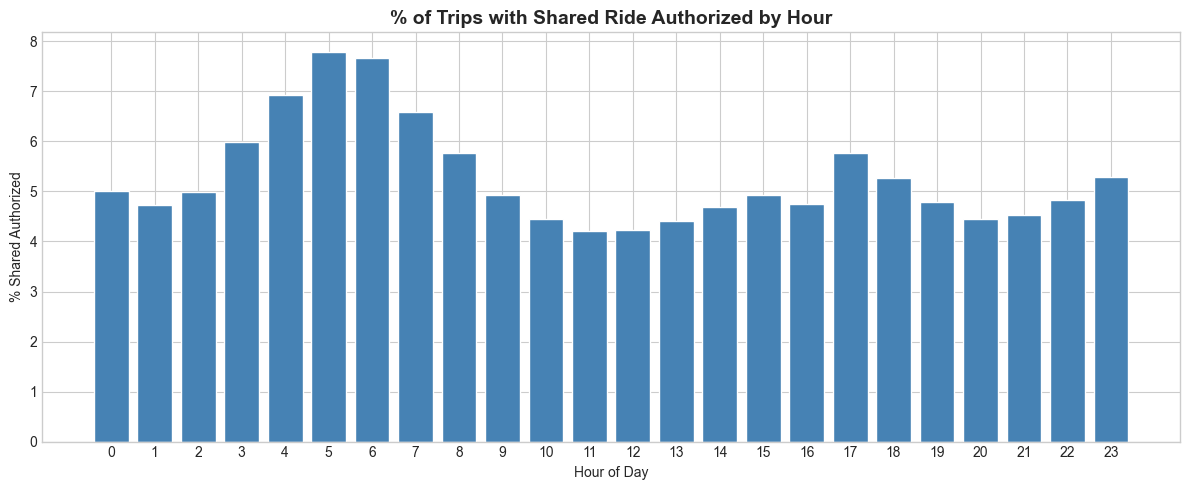

In [81]:
shared_auth_rate = df['shared_trip_authorized'].mean() * 100
shared_match_rate = df['shared_trip_match'].mean() * 100

# Of those who authorized sharing
authorized = df[df['shared_trip_authorized']]
match_rate_given_auth = authorized['shared_trip_match'].mean() * 100

print(f"Shared trip authorized: {shared_auth_rate:.1f}%")
print(f"Shared trip matched:    {shared_match_rate:.1f}%")
print(f"Match rate (given authorized): {match_rate_given_auth:.1f}%")

# Shared vs solo by hour
hourly_shared = df.groupby('hour')['shared_trip_authorized'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(hourly_shared.index, hourly_shared.values, color='steelblue', edgecolor='white')
ax.set_title('% of Trips with Shared Ride Authorized by Hour', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('% Shared Authorized')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

##### Correlation

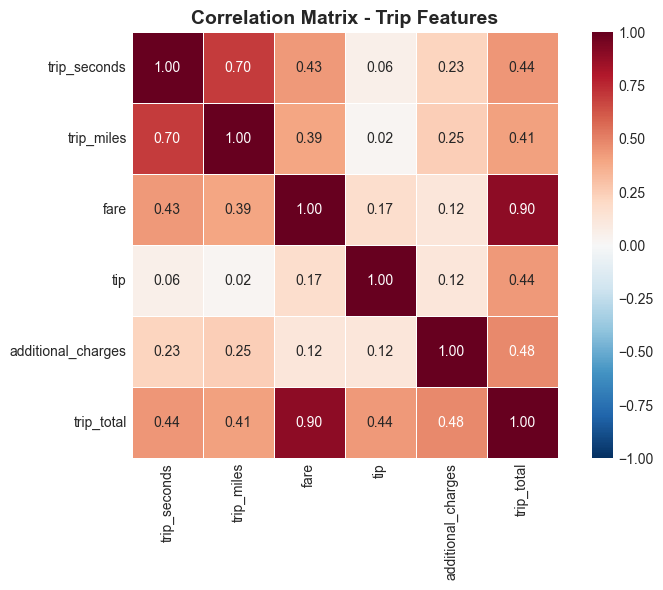

In [82]:
numeric_cols = ['trip_seconds', 'trip_miles', 'fare', 'tip', 'additional_charges', 'trip_total']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5, ax=ax, linecolor='white', vmin=-1, vmax=1)
ax.set_title('Correlation Matrix - Trip Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##### Christmas and New Year Effect

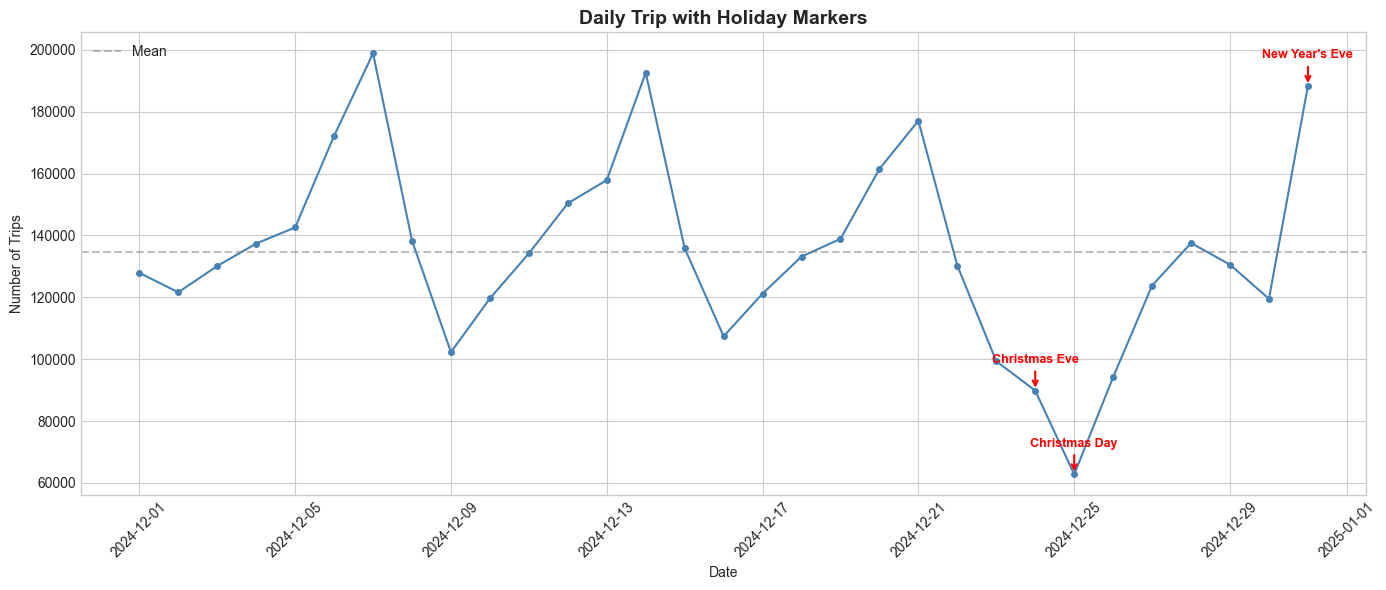

Christmas Eve: 89,830 trips (-33.3% vs mean)
Christmas Day: 62,768 trips (-53.4% vs mean)
New Year's Eve: 188,308 trips (+39.8% vs mean)


In [83]:
daily_trips = df.groupby('date').size().reset_index(name='trips')
daily_trips['date'] = pd.to_datetime(daily_trips['date'])
daily_trips['day_name'] = daily_trips['date'].dt.day_name()

# Holidays
holidays = {
    datetime.date(2024, 12, 24): 'Christmas Eve',
    datetime.date(2024, 12, 25): 'Christmas Day',
    datetime.date(2024, 12, 31): "New Year's Eve",
    datetime.date(2025, 1, 1): "New Year's Day"
}

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily_trips['date'], daily_trips['trips'], marker='o', color='steelblue', linewidth=1.5, markersize=4)
ax.set_title('Daily Trip with Holiday Markers', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Trips')

# Mark Holidays
for date, name in holidays.items():
    date = pd.Timestamp(date)
    if date in daily_trips['date'].values:
        trips_val = daily_trips.loc[daily_trips['date'] == date, 'trips'].iloc[0]
        ax.annotate(name, xy=(date, trips_val), xytext=(0, 20), textcoords='offset points', ha='center', fontsize=9, fontweight='bold', color='red', arrowprops=dict(arrowstyle='->', color='red', lw=1.5))


ax.axhline(daily_trips['trips'].mean(), color='gray', linestyle='--', alpha=0.5, label='Mean')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

mean_trips = daily_trips['trips'].mean()
for date, name in holidays.items():
    date = pd.Timestamp(date)
    if date in daily_trips['date'].values:
        trips_val = daily_trips.loc[daily_trips['date'] == date, 'trips'].iloc[0]
        pct_change = (trips_val - mean_trips) / mean_trips * 100
        print(f"{name}: {trips_val:,} trips ({pct_change:+.1f}% vs mean)")

##### Fare vs Distance

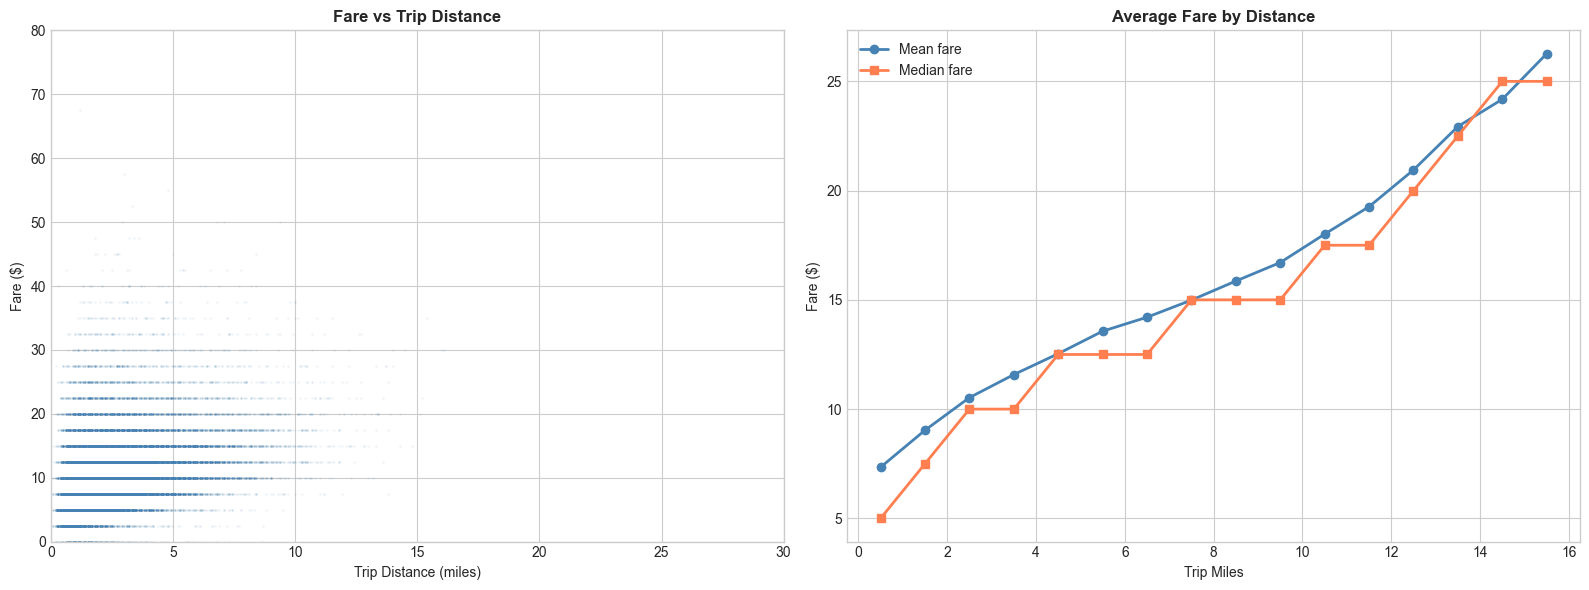

In [84]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sample = df.sample(50_000, random_state=42)
ax[0].scatter(sample['trip_miles'], sample['fare'], alpha=0.05, s=1, color='steelblue', rasterized=True)
ax[0].set_title('Fare vs Trip Distance', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Trip Distance (miles)')
ax[0].set_ylabel('Fare ($)')
ax[0].set_xlim(0, 30)
ax[0].set_ylim(0, 80)

mile_bins = pd.cut(df['trip_miles'], bins=np.arange(0, 31, 1))
avg_fare_by_mile = df.groupby(mile_bins, observed=True)['fare'].agg(['mean', 'median', 'count'])
avg_fare_by_mile = avg_fare_by_mile[avg_fare_by_mile['count'] >= 100]

x_vals = [interval.mid for interval in avg_fare_by_mile.index]
ax[1].plot(x_vals, avg_fare_by_mile['mean'], marker='o', color='steelblue', label='Mean fare', linewidth=2)
ax[1].plot(x_vals, avg_fare_by_mile['median'], marker='s', color='coral', label='Median fare', linewidth=2)
ax[1].set_title('Average Fare by Distance', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Trip Miles')
ax[1].set_ylabel('Fare ($)')
ax[1].legend()
plt.tight_layout()
plt.show()

##### Demand By Hour And Area

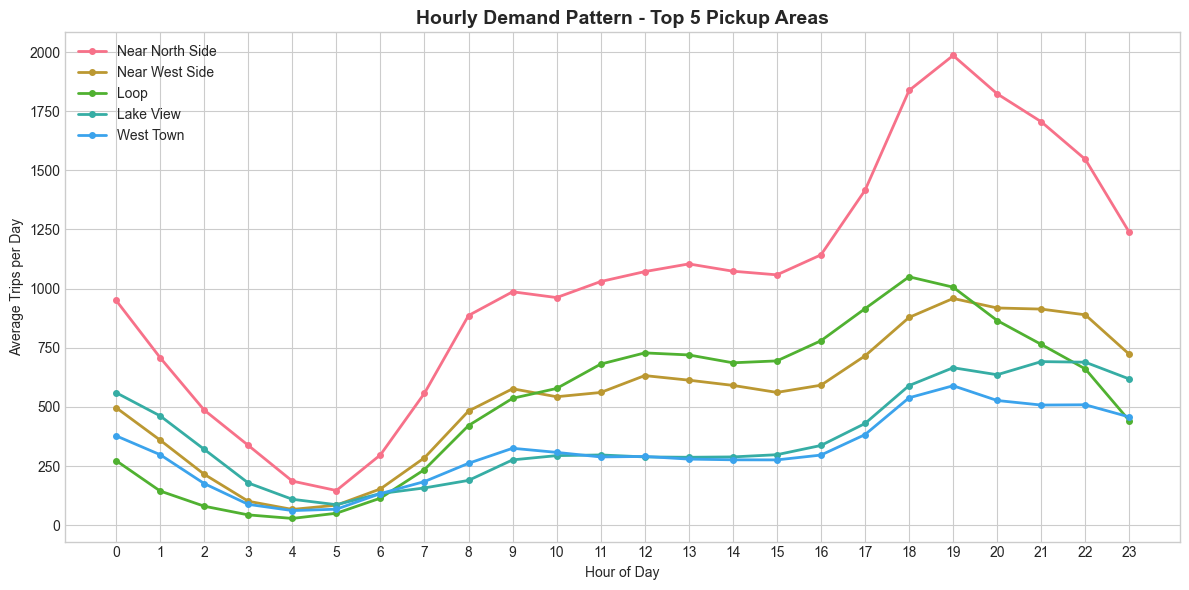

In [85]:
top5_areas = known['pickup_community_area'].value_counts().head(5).index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))

for area in top5_areas:
    area_data = df[df['pickup_community_area'] == area]
    n_days = area_data['date'].nunique()
    hourly = area_data.groupby('hour').size() / n_days
    name = area_names.get(area, f'Area {area}')
    ax.plot(hourly.index, hourly.values, marker='o', label=name, linewidth=2, markersize=4)


ax.set_title('Hourly Demand Pattern - Top 5 Pickup Areas', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Trips per Day')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

##### Trip Duration vs Hour of the Day

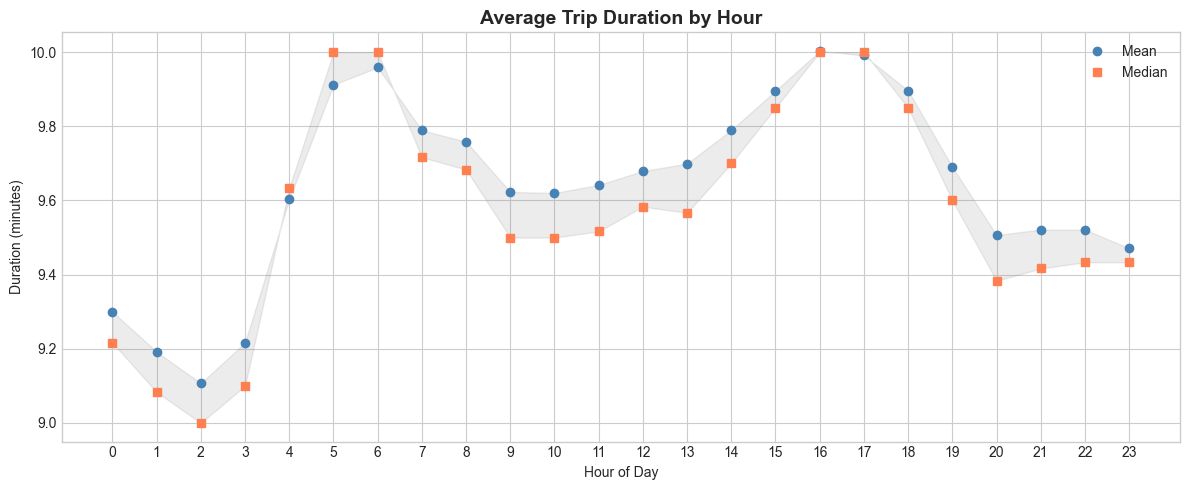

In [87]:
hourly_duration = df.groupby('hour')['trip_seconds'].agg(['mean', 'median']) / 60

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_duration.index,hourly_duration['mean'], 'o', color='steelblue', label='Mean', linewidth=2)
ax.plot(hourly_duration.index, hourly_duration['median'], 's', color='coral', label='Median', linewidth=2)
ax.set_title('Average Trip Duration by Hour', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Duration (minutes)')
ax.set_xticks(range(0, 24))
ax.legend()
ax.fill_between(hourly_duration.index, hourly_duration['median'], hourly_duration['mean'], color='gray', alpha=0.15, label='Mean-Median gap')
plt.tight_layout()
plt.show()

##### Distribution of Trips per Hour

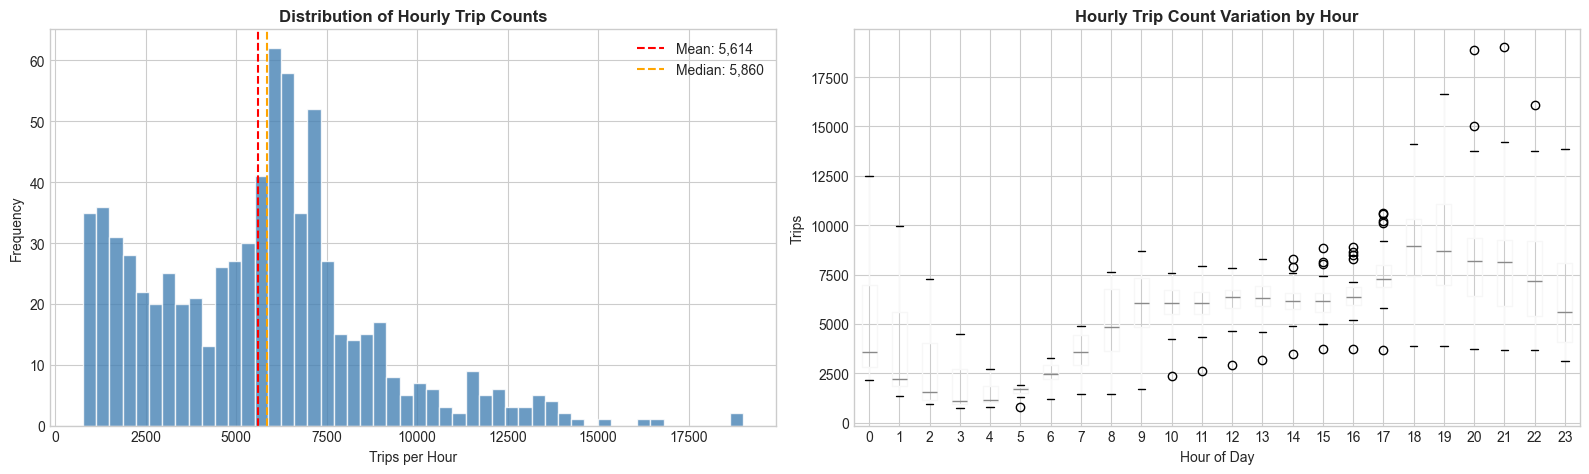

Total hourly slots: 744
Trips per hour — Mean: 5,614, Std: 3,065, Min: 764, Max: 18,998


In [88]:
hourly_counts = df.groupby([df['trip_start_timestamp'].dt.floor('h')]).size()
hourly_counts = hourly_counts.reset_index(name='trips')
hourly_counts.columns = ['timestamp', 'trips']
hourly_counts['hour'] = hourly_counts['timestamp'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(hourly_counts['trips'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Hourly Trip Counts', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Trips per Hour')
axes[0].set_ylabel('Frequency')
axes[0].axvline(hourly_counts['trips'].mean(), color='red', linestyle='--', label=f'Mean: {hourly_counts["trips"].mean():,.0f}')
axes[0].axvline(hourly_counts['trips'].median(), color='orange', linestyle='--', label=f'Median: {hourly_counts["trips"].median():,.0f}')
axes[0].legend()

hourly_counts.boxplot(column='trips', by='hour', ax=axes[1])
axes[1].set_title('Hourly Trip Count Variation by Hour',fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Trips')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f"Total hourly slots: {len(hourly_counts)}")
print(f"Trips per hour — Mean: {hourly_counts['trips'].mean():,.0f}, "
      f"Std: {hourly_counts['trips'].std():,.0f}, "
      f"Min: {hourly_counts['trips'].min():,}, "
      f"Max: {hourly_counts['trips'].max():,}")

In [89]:
df.to_parquet('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/data/processed/chirde.with_features.parquet', index=False)